In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('../data/data.csv')

print(df.head())
print(df.info())
print(df.describe())
print(df.shape)

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [6]:
#missing values
print(df.isnull().sum())


show_id          0
type             0
title            0
director        38
cast            11
country         40
date_added       0
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64


In [7]:
df["director"] = df["director"].fillna("Unknown")

In [8]:
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")

In [9]:
df.dropna(subset=["date_added"], inplace=True)
print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


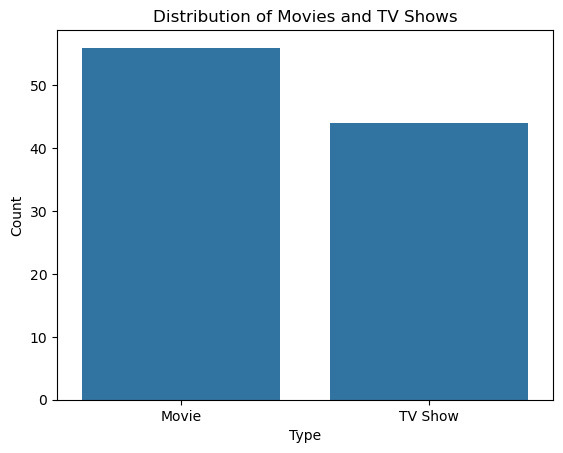

In [13]:
# Movies vs TV Shows
sns.countplot(x="type", data=df)
plt.title("Distribution of Movies and TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()


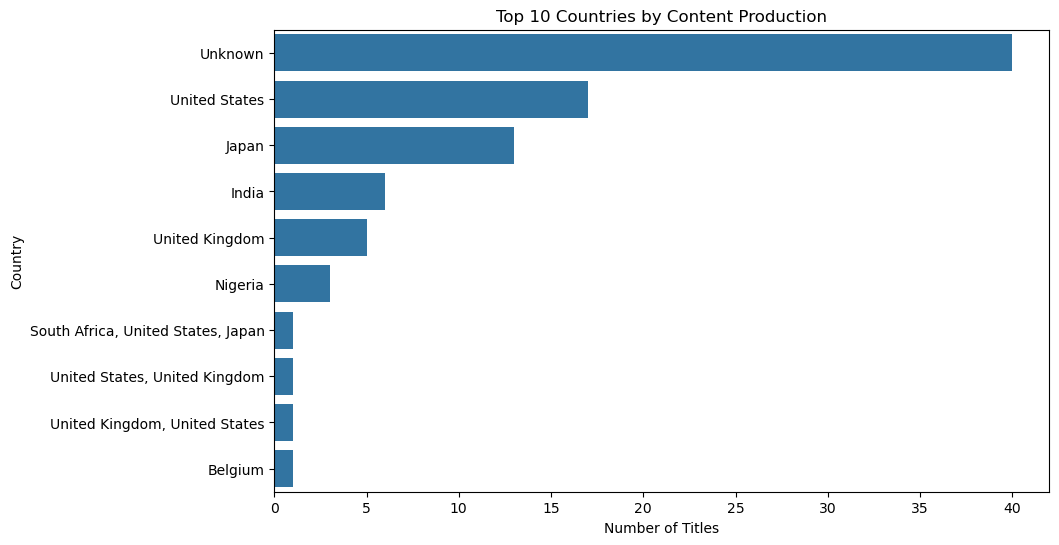

In [14]:
#Which Country Produces Most Content?
country_counts = df["country"].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=country_counts.values, y=country_counts.index)
plt.title("Top 10 Countries by Content Production")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()


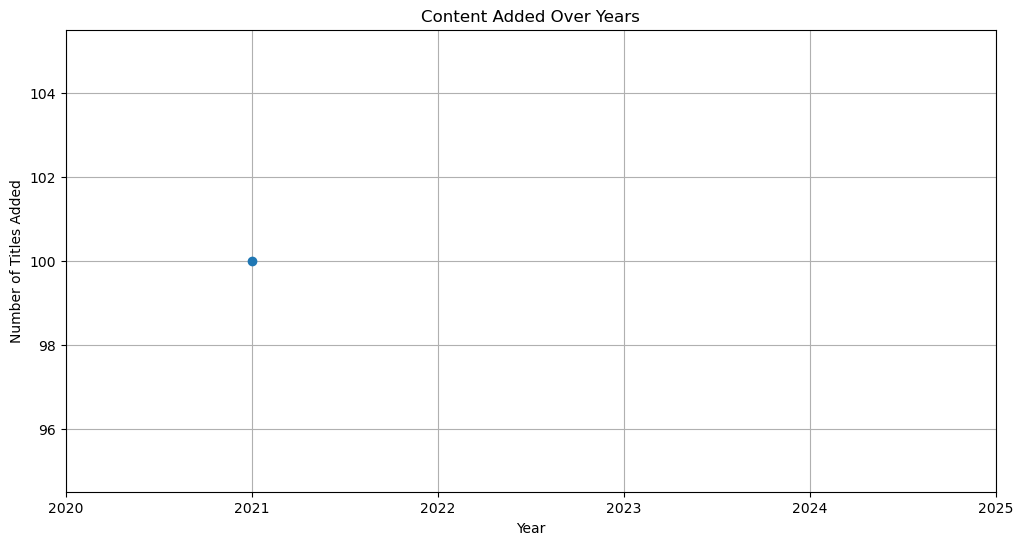

In [27]:
#Content Added Over Years
df["date_added"] = pd.to_datetime(df["date_added"])
df["year_added"] = df["date_added"].dt.year
year_counts = df["year_added"].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.plot(year_counts.index,
         year_counts.values,
         marker='o')

plt.title("Content Added Over Years")

plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.xlim(2020, 2025)   # Zoom to these years

plt.xticks(range(2020, 2026))
plt.grid(True)

plt.show()

In [30]:
print(df["year_added"].head(100))

0     2021
1     2021
2     2021
3     2021
4     2021
      ... 
95    2021
96    2021
97    2021
98    2021
99    2021
Name: year_added, Length: 100, dtype: int32


In [23]:
print(year_counts)

year_added
2021    100
Name: count, dtype: int64


In [24]:
print(df["date_added"].dtype)
print(df["date_added"].head(10))

datetime64[ns]
0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
5   2021-09-24
6   2021-09-24
7   2021-09-24
8   2021-09-24
9   2021-09-24
Name: date_added, dtype: datetime64[ns]


In [26]:
print(df.shape)

(100, 13)
